In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc
)

import shap

# Executive Summary

This report summarizes the machine learning workflow completed during Week 2.

The project involved:
 Data cleaning and preprocessing
 Feature engineering
 Training machine learning models
 Evaluating model performance

Two classification models were compared:
1. Logistic Regression
2. Random Forest

The goal was to identify the best-performing model based on predictive performance.

In [2]:
df = pd.read_csv(
    r"C:\Users\New Moon\Documents\Prosensia_AI_ML_Internship\Prosensia-AI-and-ML-Sabeeka\week2\task8\model_ready_features.csv"
)
df.head()

,sales,profit,year,month,day,quarter,is_holiday,category_Clothing,category_Electronics,category_Food,...,category_Electronics.1,category_Food.1,city_Karachi.1,city_Lahore.1,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,4954,836,2025,1,1,1,1,0,0,1,...,False,True,True,False,False,False,False,False,False,True
1,342,908,2025,1,2,1,0,0,1,0,...,True,False,True,False,False,False,False,True,False,False
2,2690,363,2025,1,3,1,0,0,0,1,...,False,True,False,False,False,False,False,False,False,False
3,1163,983,2025,1,4,1,0,0,0,1,...,False,True,True,False,False,True,False,False,False,False
4,4424,159,2025,1,5,1,0,0,1,0,...,True,False,False,True,False,False,True,False,False,False


# Data Overview

The dataset contains engineered features created from the original business data.

Key preprocessing steps:
- Date decomposition
- Weekend indicator creation
- One-hot encoding of categorical variables
- Removal of unnecessary columns

The resulting dataset was used for machine learning model training and evaluation.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape:
(500, 25)

Columns:
['sales', 'profit', 'year', 'month', 'day', 'quarter', 'is_holiday', 'category_Clothing', 'category_Electronics', 'category_Food', 'city_Islamabad', 'city_Karachi', 'city_Lahore', 'Month', 'Is_Weekend', 'category_Electronics.1', 'category_Food.1', 'city_Karachi.1', 'city_Lahore.1', 'DayOfWeek_Monday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday']


# Feature Engineering Highlights

Several new features were created to improve model performance.

### Features Created
- Year
- Month
- Day
- Is_Weekend

### Encoding
Categorical variables were converted into numerical format using One-Hot Encoding.

### Benefits
These transformations help machine learning algorithms identify patterns more effectively.

In [4]:
df["profit_class"] = (df["profit"] > df["profit"].median()).astype(int)

print(df["profit_class"].value_counts())

profit_class
1    250
0    250
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["profit", "profit_class"])
y = df["profit_class"]

print(X.shape, y.shape)

(500, 24) (500,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Done")

Train-Test Split Done


In [7]:
lr = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(random_state=42)

In [8]:
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Models Trained Successfully")

Models Trained Successfully


In [9]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [10]:
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.44
Random Forest Accuracy: 0.55


In [11]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.44
1,Random Forest,0.55


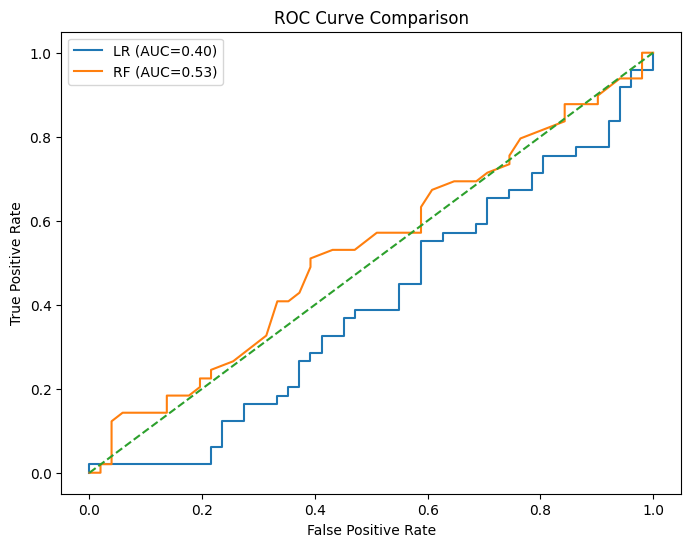

In [12]:
lr_probs = lr.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"LR (AUC={lr_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"RF (AUC={rf_auc:.2f})")

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

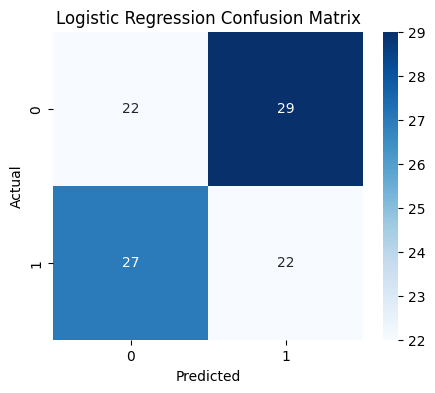

In [13]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

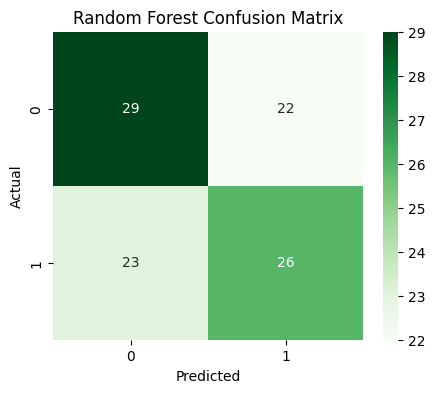

In [14]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

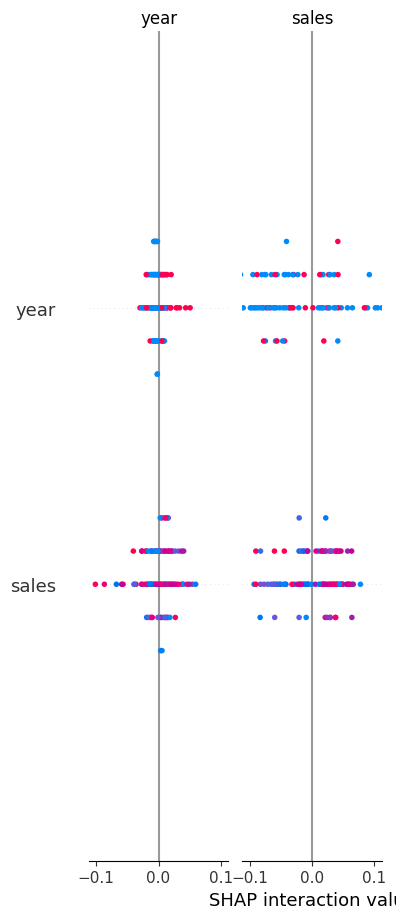

In [15]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=10)

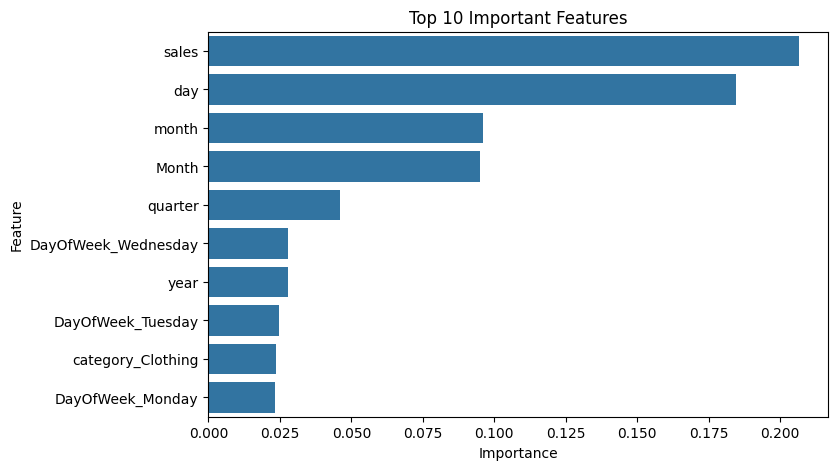

In [16]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

top10 = importances.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top10, x="Importance", y="Feature")

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Best Model

Random Forest performed better than Logistic Regression due to:
- Higher accuracy
- Better ROC-AUC score
- Strong ability to capture complex patterns

Therefore, Random Forest is selected as the final model.

# What This Means

This model analyzes past data and predicts whether profit will be high or low.

Random Forest performed best, meaning it is more reliable in making correct predictions.

This helps in understanding patterns in data and supports better decision-making.

In simple terms, it helps the business predict future outcomes using historical information.